# EDA — GPA Prediction Dataset (Model B)

**Dataset:** `student_lifestyle_dataset.csv` (2,000 rows)
**Target:** `gpa` (continuous, 0–4.0)

This EDA investigates:
1. Target distribution → check if transformation is needed
2. Feature correlations → strongest predictors of GPA
3. Categorical encoding → stress_level analysis
4. Small-data strategy → what works for 2K rows

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../../Datasets/student_lifestyle_dataset.csv")
df = df.drop(columns=["Student_ID"])
df = df.rename(columns={
    "Study_Hours_Per_Day": "study_hours",
    "Extracurricular_Hours_Per_Day": "eca_hours",
    "Sleep_Hours_Per_Day": "sleep_hours",
    "Social_Hours_Per_Day": "social_hours",
    "Physical_Activity_Hours_Per_Day": "physical_hours",
    "Stress_Level": "stress_level",
    "GPA": "gpa",
})

print(f"Shape: {df.shape}")
df.head()

Shape: (2000, 7)


,study_hours,eca_hours,sleep_hours,social_hours,physical_hours,gpa,stress_level
0,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,8.1,0.6,6.5,2.2,6.6,3.51,High


In [24]:
df.info()
print()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     2000 non-null   float64
 1   eca_hours       2000 non-null   float64
 2   sleep_hours     2000 non-null   float64
 3   social_hours    2000 non-null   float64
 4   physical_hours  2000 non-null   float64
 5   gpa             2000 non-null   float64
 6   stress_level    2000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 109.5+ KB



,count,mean,std,min,25%,50%,75%,max
study_hours,2000.0,7.47580,1.423888,5.00,6.3,7.40,8.70,10.0
eca_hours,2000.0,1.99010,1.155855,0.00,1.0,2.00,3.00,4.0
sleep_hours,2000.0,7.50125,1.460949,5.00,6.2,7.50,8.80,10.0
social_hours,2000.0,2.70455,1.688514,0.00,1.2,2.60,4.10,6.0
physical_hours,2000.0,4.32830,2.514110,0.00,2.4,4.10,6.10,13.0
gpa,2000.0,3.11596,0.298674,2.24,2.9,3.11,3.33,4.0


In [25]:
df.isnull().sum()

study_hours       0
eca_hours         0
sleep_hours       0
social_hours      0
physical_hours    0
gpa               0
stress_level      0
dtype: int64

## 1. Target Variable Analysis — `gpa`

Skewness : 0.0275
Kurtosis : -0.3707
Mean     : 3.1160
Median   : 3.1100
Std      : 0.2987
Min/Max  : 2.2400 / 4.0000

>>> Target is roughly symmetric. Transformation optional.


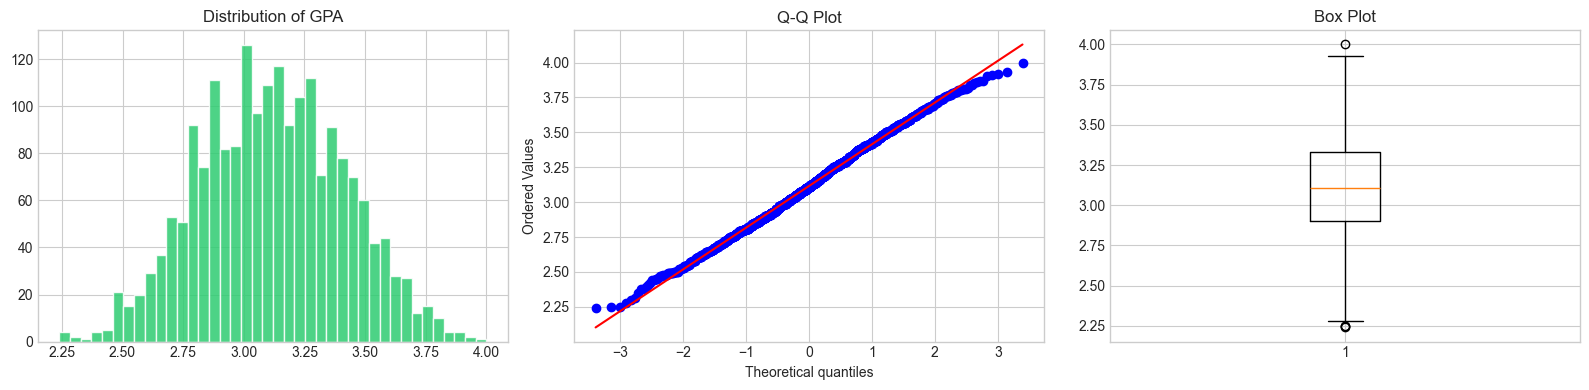

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["gpa"], bins=40, color="#2ecc71", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of GPA")

stats.probplot(df["gpa"], plot=axes[1])
axes[1].set_title("Q-Q Plot")

axes[2].boxplot(df["gpa"], vert=True)
axes[2].set_title("Box Plot")

skew = df["gpa"].skew()
kurt = df["gpa"].kurtosis()
print(f"Skewness : {skew:.4f}")
print(f"Kurtosis : {kurt:.4f}")
print(f"Mean     : {df['gpa'].mean():.4f}")
print(f"Median   : {df['gpa'].median():.4f}")
print(f"Std      : {df['gpa'].std():.4f}")
print(f"Min/Max  : {df['gpa'].min():.4f} / {df['gpa'].max():.4f}")

if abs(skew) > 0.5:
    print(f"\n>>> Target is SKEWED. Consider transformation.")
else:
    print(f"\n>>> Target is roughly symmetric. Transformation optional.")

plt.tight_layout()
plt.show()

## 2. Stress Level Analysis

In [27]:
print("Stress Level value counts:")
print(df["stress_level"].value_counts())
print()
print("GPA by stress level:")
print(df.groupby("stress_level")["gpa"].agg(["mean", "std", "count"]))
print()
print("Study hours by stress level:")
print(df.groupby("stress_level")["study_hours"].agg(["mean", "std"]))

Stress Level value counts:
stress_level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

GPA by stress level:
                  mean       std  count
stress_level                           
High          3.261973  0.274960   1029
Low           2.816869  0.215396    297
Moderate      3.024837  0.220653    674

Study hours by stress level:
                  mean       std
stress_level                    
High          8.385034  1.238311
Low           5.474411  0.279753
Moderate      6.969585  0.597576


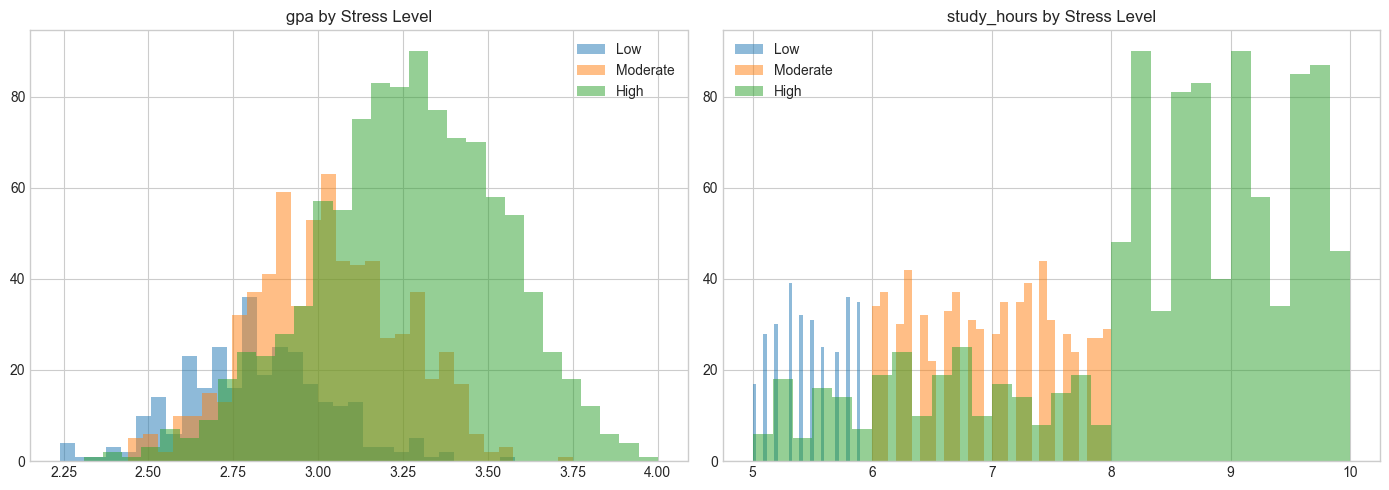

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(["gpa", "study_hours"]):
    for level in ["Low", "Moderate", "High"]:
        subset = df[df["stress_level"] == level][target]
        axes[i].hist(subset, bins=30, alpha=0.5, label=level)
    axes[i].set_title(f"{target} by Stress Level")
    axes[i].legend()
plt.tight_layout()
plt.show()

## 3. Feature Correlations with GPA

In [29]:
df_encoded = df.copy()
df_encoded["stress_level"] = df_encoded["stress_level"].map({"Low": 0, "Moderate": 1, "High": 2})

corr = df_encoded.corr()["gpa"].drop("gpa").sort_values(ascending=False)
print("Correlation with GPA:")
print("=" * 40)
for feat, val in corr.items():
    bar = "+" * int(abs(val) * 30) if val > 0 else "-" * int(abs(val) * 30)
    print(f"  {feat:20s} : {val:+.4f}  {bar}")

Correlation with GPA:
  study_hours          : +0.7345  ++++++++++++++++++++++
  stress_level         : +0.5504  ++++++++++++++++
  sleep_hours          : -0.0043  
  eca_hours            : -0.0322  
  social_hours         : -0.0857  --
  physical_hours       : -0.3412  ----------


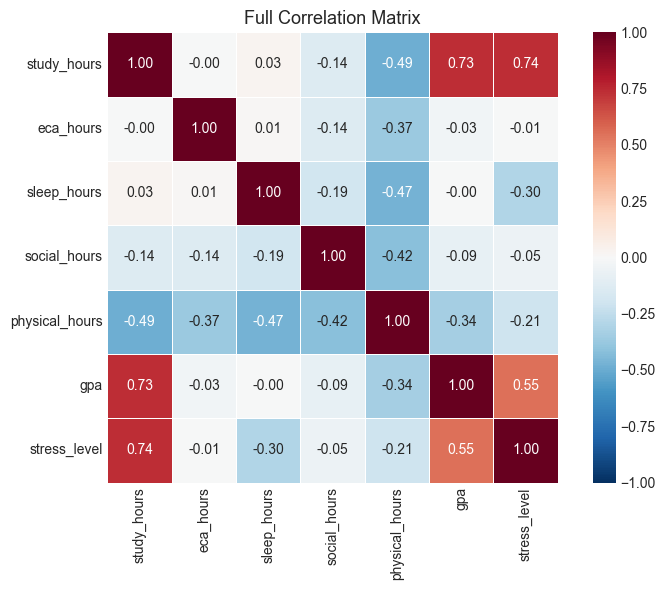

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Full Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Feature vs GPA Scatter Plots

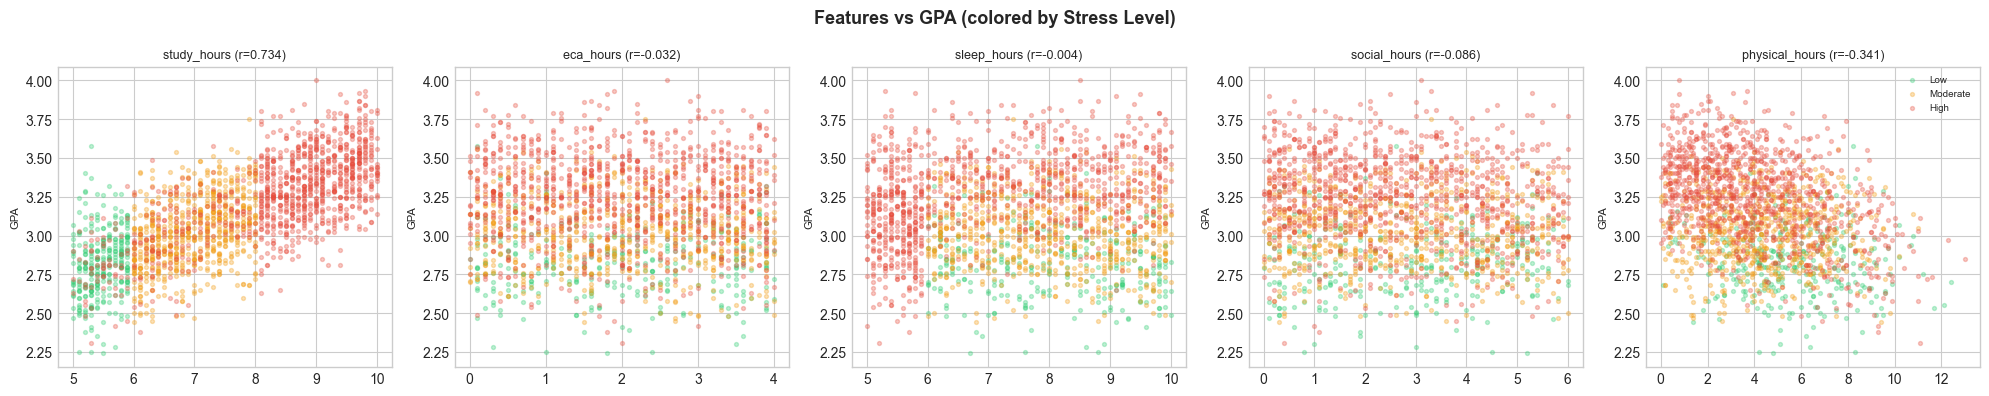

In [31]:
num_cols = ["study_hours", "eca_hours", "sleep_hours", "social_hours", "physical_hours"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    for level, color in [("Low", "#2ecc71"), ("Moderate", "#f39c12"), ("High", "#e74c3c")]:
        subset = df[df["stress_level"] == level]
        axes[i].scatter(subset[col], subset["gpa"], alpha=0.3, s=8, color=color, label=level)
    r = df_encoded[col].corr(df_encoded["gpa"])
    axes[i].set_title(f"{col} (r={r:.3f})", fontsize=9)
    axes[i].set_ylabel("GPA", fontsize=8)
    if i == 4:
        axes[i].legend(fontsize=7)

plt.suptitle("Features vs GPA (colored by Stress Level)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Outlier Analysis

In [32]:
num_df = df_encoded.select_dtypes("number")
z_scores = np.abs(stats.zscore(num_df))
outlier_mask = (z_scores >= 3).any(axis=1)
print(f"Rows with any |z| >= 3: {outlier_mask.sum()} out of {len(df)}")
print(f"Percentage: {outlier_mask.sum()/len(df)*100:.2f}%")

for col in num_df.columns:
    n_out = (np.abs(stats.zscore(num_df[col])) >= 3).sum()
    if n_out > 0:
        print(f"  {col}: {n_out} outliers")

Rows with any |z| >= 3: 4 out of 2000
Percentage: 0.20%
  physical_hours: 4 outliers


## 6. Inter-Feature Relationships

In [33]:
high_corr = []
cols = num_df.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = num_df[cols[i]].corr(num_df[cols[j]])
        if abs(r) > 0.3:
            high_corr.append((cols[i], cols[j], r))

print("Notable inter-feature correlations (|r| > 0.3):")
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {a:20s} <-> {b:20s} : {r:+.3f}")

Notable inter-feature correlations (|r| > 0.3):
  study_hours          <-> stress_level         : +0.739
  study_hours          <-> gpa                  : +0.734
  gpa                  <-> stress_level         : +0.550
  study_hours          <-> physical_hours       : -0.488
  sleep_hours          <-> physical_hours       : -0.470
  social_hours         <-> physical_hours       : -0.417
  eca_hours            <-> physical_hours       : -0.370
  physical_hours       <-> gpa                  : -0.341


## 7. Summary & Recommendations for Model B

1. **GPA is roughly symmetric** → Target transformation optional but worth testing
2. **Only 2,000 rows** → Heavy regularization, 10-fold CV, no aggressive cleaning
3. **study_hours is the dominant predictor** (r≈0.73) → interactions with stress_level are key
4. **physical_hours negatively correlates** with GPA (r≈-0.34) → students who exercise more study less
5. **Feature engineering priorities**:
   - study_hours × stress_level (both top predictors)
   - study_hours / (leisure time) ratios
   - Non-linear terms for study_hours (strongest predictor)
6. **Diverse model ensemble** works best for small data (different inductive biases)